In [3]:
# load dataset
import pandas as pd

df = pd.read_csv("spam.csv", encoding="latin-1")

print(df.head())
print(df.shape)
print(df.columns)

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
(5572, 5)
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [7]:
#check whether there are missing values and confirm the labels in dataset.
print("Dataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nMessage categories:")
print(df["v1"].value_counts())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB
None

Missing values:
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

Message categories:
v1
ham     4825
spam     747
Name: count, dtype: int64


In [8]:
#keep only two important columns
df = df[["v1", "v2"]]

print(df.head())
print(df.shape)

     v1                                                 v2
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
(5572, 2)


In [9]:
#rename the columns to meaningful names
df = df.rename(columns={
    "v1": "label",
    "v2": "message"
})

print(df.head())
print(df.columns)

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Index(['label', 'message'], dtype='object')


In [10]:
# Check for missing values
print(df.isnull().sum())

label      0
message    0
dtype: int64


In [11]:
# Remove any empty rows
df = df.dropna()

print("Dataset shape:", df.shape)

Dataset shape: (5572, 2)


In [13]:
# Convert ham and spam into numbers
df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

print(df.head())

   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [14]:
#Separate input and output
X = df["message"]
y = df["label"]

print("X:", X.shape)
print("y:", y.shape)

X: (5572,)
y: (5572,)


In [15]:
#Split the dataset 80%  for training data and 20% testing data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))

Training messages: 4457
Testing messages: 1115


In [17]:
print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))

Training messages: 4457
Testing messages: 1115


In [18]:
#TF-IDF Vectorization(convert the text messages into numbers so ml model can understand)
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer()

# Learn vocabulary from training data and transform it
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform testing data using the same vocabulary
X_test_tfidf = vectorizer.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (4457, 7701)
Testing shape: (1115, 7701)


In [19]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [20]:
X_test_tfidf = vectorizer.transform(X_test)

In [21]:
#Train the model
from sklearn.naive_bayes import MultinomialNB

# Create the model
model = MultinomialNB()

# Train the model
model.fit(X_train_tfidf, y_train)

print("Model trained successfully!")

Model trained successfully!


In [22]:
# Predict the test messages
y_pred = model.predict(X_test_tfidf)

print("Predictions completed!")
print("First 10 predictions:", y_pred[:10])

Predictions completed!
First 10 predictions: [0 0 0 1 0 0 0 0 0 0]


In [23]:
#Calculate all important evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Ham", "Spam"]
))

Accuracy : 0.9605381165919282
Precision: 1.0
Recall   : 0.7046979865771812
F1 Score : 0.8267716535433071

Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       1.00      0.70      0.83       149

    accuracy                           0.96      1115
   macro avg       0.98      0.85      0.90      1115
weighted avg       0.96      0.96      0.96      1115



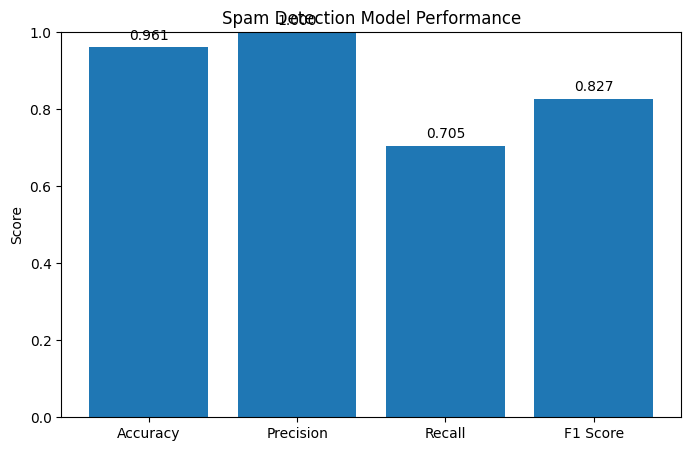

In [24]:
#Accuracy, Precision, Recall & F1
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Spam Detection Model Performance")

for i, value in enumerate(values):
    plt.text(i, value + 0.02, f"{value:.3f}", ha="center")

plt.show()

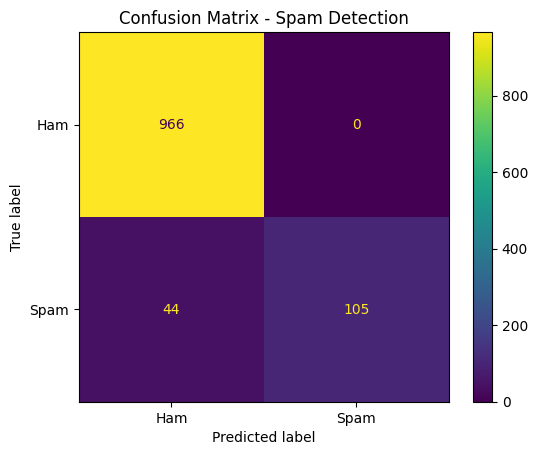

In [25]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot()

plt.title("Confusion Matrix - Spam Detection")
plt.show()

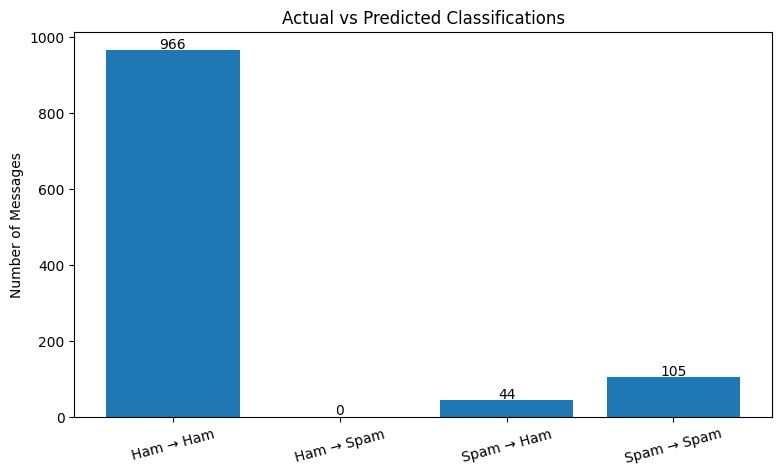

In [26]:
#Actual vs Predicted
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

counts = comparison.value_counts().sort_index()

labels = [
    "Ham → Ham",
    "Ham → Spam",
    "Spam → Ham",
    "Spam → Spam"
]

values = [
    counts.get((0, 0), 0),
    counts.get((0, 1), 0),
    counts.get((1, 0), 0),
    counts.get((1, 1), 0)
]

plt.figure(figsize=(9, 5))
plt.bar(labels, values)

plt.ylabel("Number of Messages")
plt.title("Actual vs Predicted Classifications")
plt.xticks(rotation=15)

for i, value in enumerate(values):
    plt.text(i, value + 5, str(value), ha="center")

plt.show()